# 01 — EDA & Data Cleaning
Eksplorasi awal dan pembersihan data e-commerce sebelum masuk ke pemodelan ML.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 1. Load Data

In [12]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (5000, 17)


,order_id,order_date,customer_name,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,payment_mode,month,year,is_trending
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.60,10525.09,Debit Card,10,2024,0
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.00,6299.66,Debit Card,8,2025,0
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.20,19850.27,Credit Card,11,2023,1
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.00,36311.02,UPI,5,2025,1
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.30,9050.04,Debit Card,1,2025,0
5,10006,2025-04-06,Vardaniya Jayaraman,West,Pune,Furniture,Chair,Chair Assumenda,5,40287,15,171219.75,23722.84,Credit Card,4,2025,1
6,10007,2023-10-13,Drishya Khare,West,Mumbai,Clothing,Accessories,Accessories Minima,2,3636,5,6908.40,680.26,Debit Card,10,2023,0
7,10008,2025-08-17,Misha Dua,North,Lucknow,Books,Biography,Biography Vel,1,15885,10,14296.50,1289.03,Debit Card,8,2025,0
8,10009,2025-03-07,Arhaan Vala,North,Jaipur,Groceries,Spices,Spices Expedita,1,40834,20,32667.20,3700.89,Credit Card,3,2025,0
9,10010,2024-12-02,Lavanya Hayer,West,Goa,Kitchen,Juicer,Juicer Voluptatibus,2,16686,15,28366.20,5703.09,UPI,12,2024,0


## 2. Informasi Dataset

In [13]:
print('=== INFO ===')
df.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe().round(2)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5000 non-null   int64  
 1   order_date     5000 non-null   object 
 2   customer_name  5000 non-null   object 
 3   region         5000 non-null   object 
 4   city           5000 non-null   object 
 5   category       5000 non-null   object 
 6   sub_category   5000 non-null   object 
 7   product_name   5000 non-null   object 
 8   quantity       5000 non-null   int64  
 9   unit_price     5000 non-null   int64  
 10  discount       5000 non-null   int64  
 11  sales          5000 non-null   float64
 12  profit         5000 non-null   float64
 13  payment_mode   5000 non-null   object 
 14  month          5000 non-null   int64  
 15  year           5000 non-null   int64  
 16  is_trending    5000 non-null   int64  
dtypes: float64(2), int64(7), object(8)
memo

,order_id,quantity,unit_price,discount,sales,profit,month,year,is_trending
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12500.50,2.99,39760.90,10.05,106733.20,15941.75,6.48,2024.25,0.40
std,1443.52,1.41,22831.78,7.08,85108.21,14897.68,3.44,0.66,0.49
min,10001.00,1.00,222.00,0.00,264.10,19.12,1.00,2023.00,0.00
25%,11250.75,2.00,20312.25,5.00,39766.54,4892.30,4.00,2024.00,0.00
50%,12500.50,3.00,39459.50,10.00,83080.32,11108.53,6.00,2024.00,0.00
75%,13750.25,4.00,59721.75,15.00,156968.59,22467.99,9.00,2025.00,1.00
max,15000.00,5.00,79998.00,20.00,398485.00,89688.44,12.00,2025.00,1.00


## 3. Cek Missing Values & Duplikat

In [14]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '✅ Tidak ada missing value!')
print()
print(f'=== DUPLIKAT ===')
dup = df.duplicated().sum()
print(f'Jumlah duplikat: {dup}' if dup > 0 else '✅ Tidak ada duplikat!')

=== MISSING VALUES ===
✅ Tidak ada missing value!

=== DUPLIKAT ===
✅ Tidak ada duplikat!


## 4. Distribusi Kolom Numerik

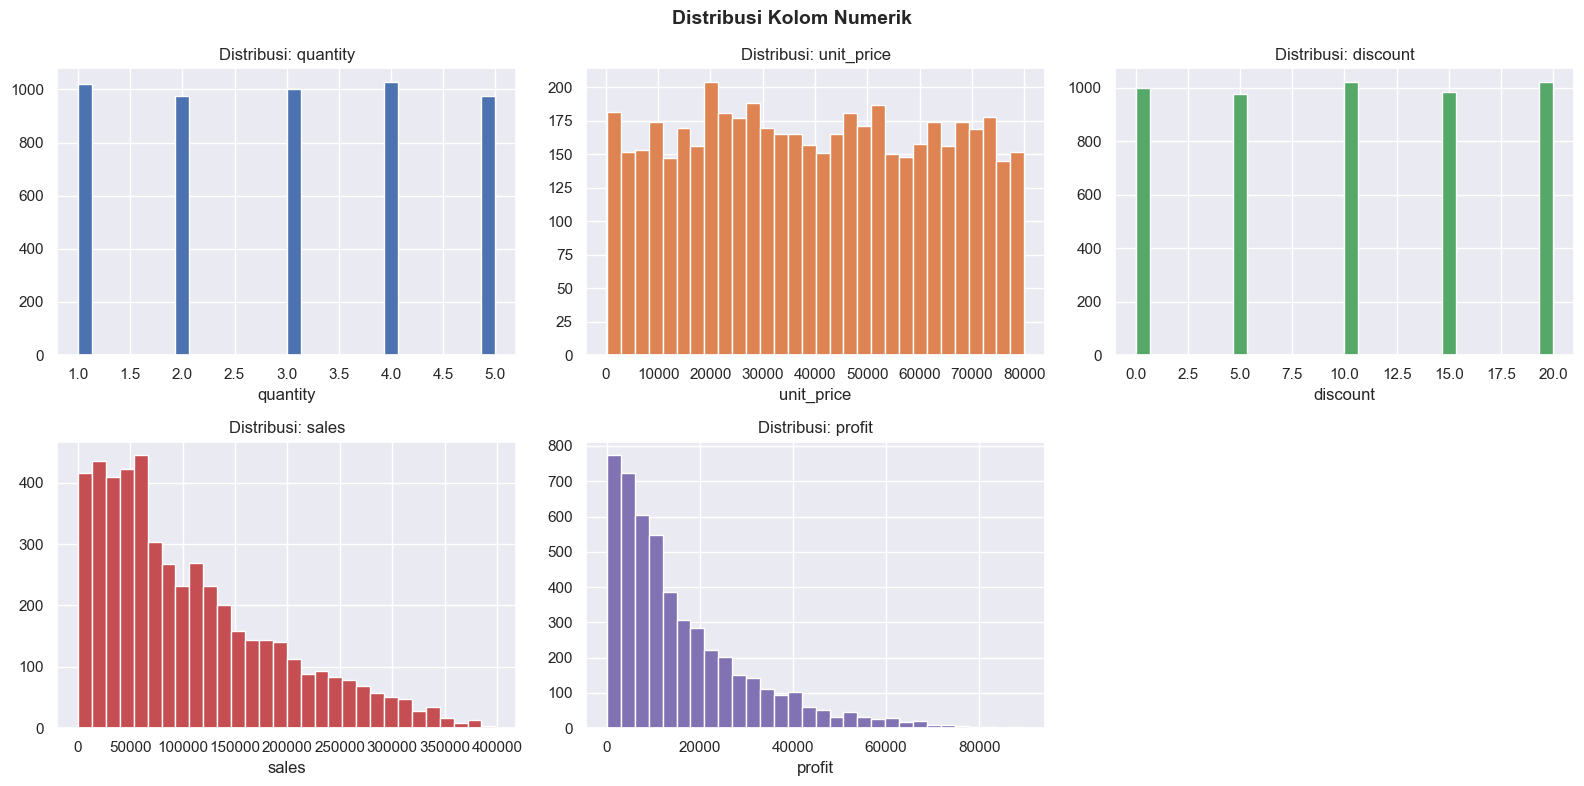

In [15]:
num_cols = ['quantity', 'unit_price', 'discount', 'sales', 'profit']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', color=sns.color_palette()[i])
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
axes[-1].set_visible(False)
plt.suptitle('Distribusi Kolom Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distribusi Kolom Kategorikal

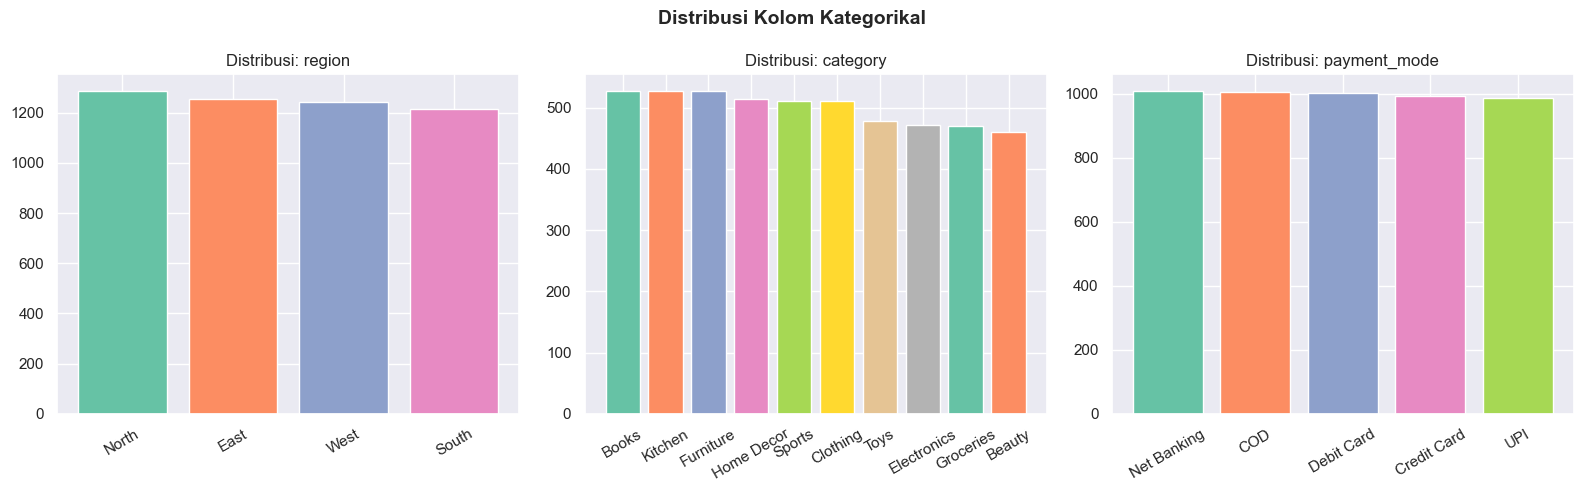

In [16]:
cat_cols = ['region', 'category', 'payment_mode']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('Set2'))
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Distribusi Kolom Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Korelasi Antar Fitur Numerik

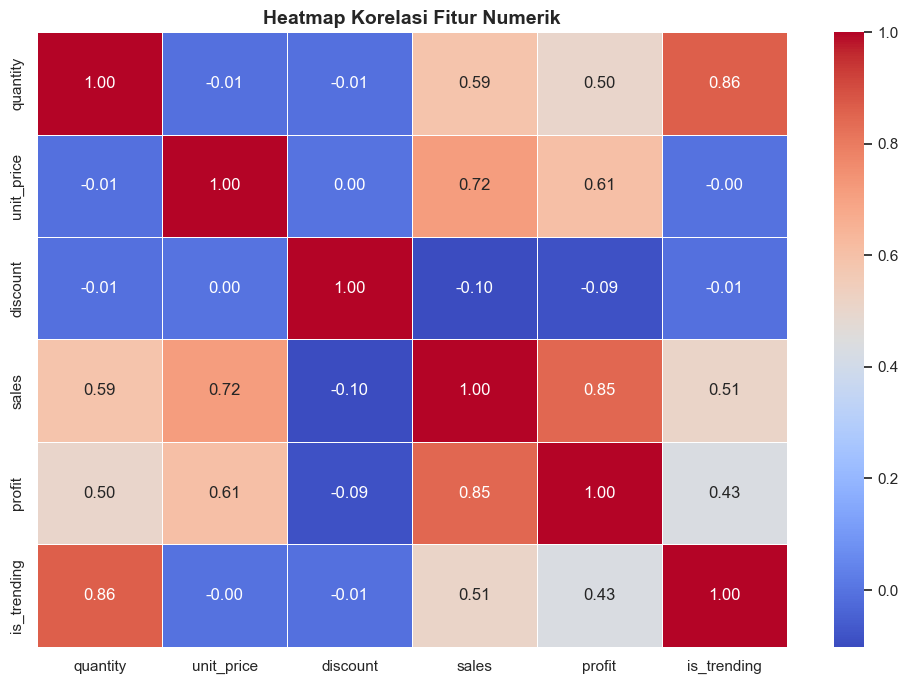

In [17]:
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['is_trending']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Engineering (Simpan ke Processed)

In [18]:
df['profit_margin'] = (df['profit'] / df['sales']) * 100
df['revenue_per_unit'] = df['sales'] / df['quantity']
df['log_sales'] = np.log1p(df['sales'])
df['order_date'] = pd.to_datetime(df['order_date'])

print('Fitur baru ditambahkan:')
print('  ➕ profit_margin (%)  → profit / sales * 100')
print('  ➕ revenue_per_unit   → sales / quantity')
print('  ➕ log_sales          → log transform sales')
df[['sales','profit','profit_margin','revenue_per_unit','log_sales']].describe().round(2)

Fitur baru ditambahkan:
  ➕ profit_margin (%)  → profit / sales * 100
  ➕ revenue_per_unit   → sales / quantity
  ➕ log_sales          → log transform sales


,sales,profit,profit_margin,revenue_per_unit,log_sales
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,106733.20,15941.75,14.92,35763.77,11.14
std,85108.21,14897.68,5.74,20810.82,1.11
min,264.10,19.12,5.00,182.40,5.58
25%,39766.54,4892.30,9.93,18016.15,10.59
50%,83080.32,11108.53,14.97,35428.68,11.33
75%,156968.59,22467.99,19.82,53414.26,11.96
max,398485.00,89688.44,25.00,79930.00,12.90


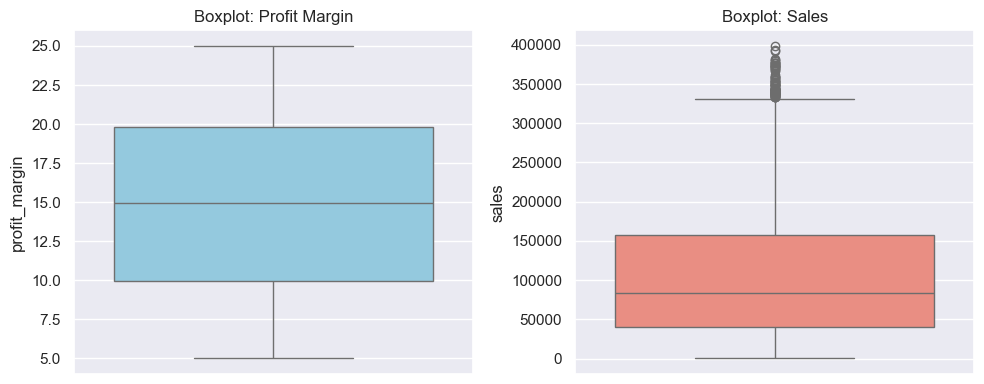

✅ EDA selesai! Data siap dipakai untuk notebook selanjutnya.


In [19]:
# Outlier check: boxplot profit_margin
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.boxplot(y=df['profit_margin'], color='skyblue')
plt.title('Boxplot: Profit Margin')

plt.subplot(1,2,2)
sns.boxplot(y=df['sales'], color='salmon')
plt.title('Boxplot: Sales')
plt.tight_layout()
plt.show()

print('✅ EDA selesai! Data siap dipakai untuk notebook selanjutnya.')